# M4Raw Exploratory Data Analysis

This notebook supports the reconstructor and the risk-controlled gate. It measures the things the design rests on. These are the contrast strata, the k-space geometry, and the intensity scale. It also measures the SNR gained by averaging repetitions. It shows what undersampling does to a slice.

All paths are relative. Put the unzipped M4Raw `.h5` files under a relative `data` folder, or change `DATA_DIR`. The notebook reuses `data_processing.py`, so the transforms, mask, and readers here are exactly the ones the model trains on.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import torch

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "EDA" else HERE
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "data"))

from data_processing import scan_index, kspace_slice, rss_slices, cartesian_mask, zero_filled

SEED = 0
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
ART_DIR.mkdir(parents=True, exist_ok=True)

ACCELERATIONS = (4, 8)
CENTER_FRACTION = 0.08
CORNER = 12
rng = np.random.default_rng(SEED)

index = scan_index(DATA_DIR)
print(f"files: {len(index)} | studies: {index['study'].nunique()}")


files: 1264 | studies: 158


## Contrast strata and repetitions
Contrast is the grouping the model and any per-group calibration condition on. The repetition count per scan is what makes the clean target possible (more repetitions, cleaner average).

In [2]:
def contrast_table(frame):
    """Files and distinct studies per contrast."""
    table = frame.groupby("contrast").agg(files=("path", "size"), studies=("study", "nunique"))
    return table


def reps_per_scan(frame):
    """Distribution of repetition counts across scans."""
    counts = frame.groupby(["study", "contrast"]).size()
    return counts.value_counts().rename_axis("repetitions").rename("scans")


print(contrast_table(index))
print()
print(reps_per_scan(index))


          files  studies
contrast                
FLAIR       316      158
T1          474      158
T2          474      158

repetitions
3    316
2    158
Name: scans, dtype: int64


## k-space geometry
Confirms coil count and matrix size, and whether sizes vary across volumes (which would force a crop or batch size of one).

In [3]:
def geometry(paths):
    """k-space and image shapes for a list of files, as a table."""
    rows = []
    for path in paths:
        with h5py.File(path, "r") as handle:
            rows.append((Path(path).name, *handle["kspace"].shape, *handle["reconstruction_rss"].shape))
    columns = ["file", "slices", "coils", "kx", "ky", "img_slices", "img_h", "img_w"]
    return pd.DataFrame(rows, columns=columns)


sample_paths = index["path"].sample(min(8, len(index)), random_state=SEED).tolist()
shapes = geometry(sample_paths)
print(shapes)
print("distinct (coils, kx, ky):", shapes[["coils", "kx", "ky"]].drop_duplicates().to_dict("records"))


                 file  slices  coils   kx   ky  img_slices  img_h  img_w
0  2022090104_T102.h5      18      4  256  256          18    256    256
1  2022062503_T102.h5      18      4  256  256          18    256    256
2  2022090906_T102.h5      18      4  256  256          18    256    256
3  2022061001_T201.h5      18      4  256  256          18    256    256
4  2022090104_T201.h5      18      4  256  256          18    256    256
5  2022062702_T102.h5      18      4  256  256          18    256    256
6  2022090904_T102.h5      18      4  256  256          18    256    256
7  2022090501_T101.h5      18      4  256  256          18    256    256
distinct (coils, kx, ky): [{'coils': 4, 'kx': 256, 'ky': 256}]


## SNR gain from averaging repetitions
The centerpiece of the project. The clean target is the repetition average. The noisy input is a single repetition. This quantifies the gap, which is the difficulty signal the gate exists to exploit.

In [4]:
def noise_floor(image, margin):
    """Background noise standard deviation from the four image corners."""
    corners = torch.cat([
        image[:margin, :margin].flatten(), image[:margin, -margin:].flatten(),
        image[-margin:, :margin].flatten(), image[-margin:, -margin:].flatten(),
    ])
    return float(corners.std())


def snr(image, margin):
    """Central signal mean over corner noise standard deviation."""
    h, w = image.shape
    core = image[h // 4:3 * h // 4, w // 4:3 * w // 4]
    return float(core.mean()) / (noise_floor(image, margin) + 1e-8)


scans = index.sort_values("rep").groupby(["study", "contrast"])["path"].apply(list)
multi = next(paths for paths in scans if len(paths) > 1)
mid = 9
reps = rss_slices(multi, mid)
single, averaged = reps[0], reps.mean(dim=0)
print(f"single-repetition SNR: {snr(single, CORNER):.2f}")
print(f"averaged SNR:          {snr(averaged, CORNER):.2f}")


single-repetition SNR: 15.72
averaged SNR:          20.05


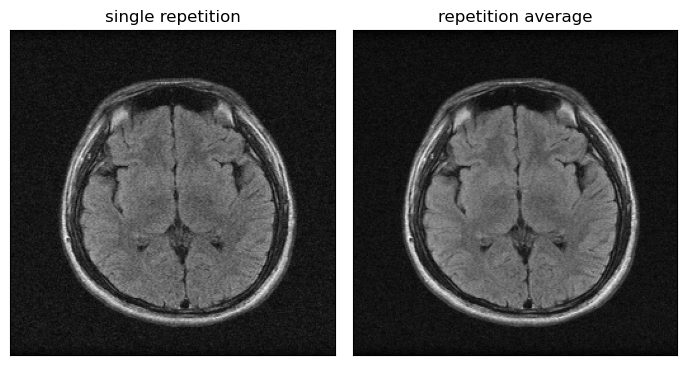

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
for ax, image, name in zip(axes, (single, averaged), ("single repetition", "repetition average")):
    ax.imshow(image.numpy(), cmap="gray")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
fig.savefig(ART_DIR / "repetition_snr.png", dpi=150, bbox_inches="tight")
plt.show()


## Intensity scale per contrast
The reconstruction images are not in a fixed range. The median and high percentile per contrast set the normalization the training loss and uncertainty depend on.

In [6]:
def intensity_summary(frame, n, rng):
    """Median and 99th-percentile image intensity per contrast over sampled files."""
    rows = []
    for contrast, group in frame.groupby("contrast"):
        picks = group["path"].sample(min(n, len(group)), random_state=int(rng.integers(1_000_000)))
        values = np.concatenate([h5py.File(p, "r")["reconstruction_rss"][:].ravel() for p in picks])
        rows.append((contrast, float(np.median(values)), float(np.percentile(values, 99))))
    return pd.DataFrame(rows, columns=["contrast", "median", "p99"])


print(intensity_summary(index, 4, rng).round(4))


  contrast   median      p99
0    FLAIR  11.1967  66.3059
1       T1  10.8489  93.0034
2       T2  10.4931  60.0832


## k-space central-energy concentration
A sanity check on the mask. Most energy sits in the central phase-encode lines, which is why the autocalibration center stays fully sampled.

In [7]:
def center_energy(kspace, fraction):
    """Share of total k-space energy within the central phase-encode band."""
    energy = (kspace.abs() ** 2).sum(dim=-3)
    width = energy.shape[-1]
    band = round(width * fraction)
    start = (width - band) // 2
    return float(energy[:, start:start + band].sum() / (energy.sum() + 1e-8))


probe = kspace_slice(index["path"].iloc[0], mid)
print(f"energy in central {int(CENTER_FRACTION * 100)}% of lines: {center_energy(probe, CENTER_FRACTION):.3f}")


energy in central 8% of lines: 0.804


## Undersampling preview
This shows what the cheap reconstructor faces. It puts the clean reference against zero-filled inputs at each acceleration. The gap here is what the reconstructor has to close.

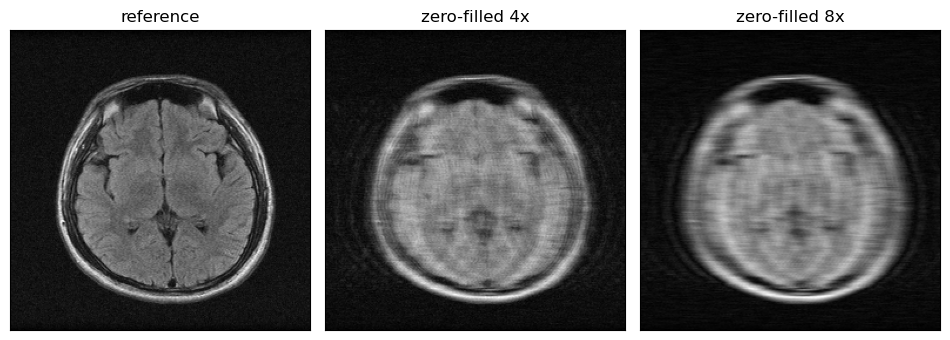

In [8]:
def undersampling_figure(reference, kspace, accelerations, center_fraction, rng):
    """Reference image beside zero-filled reconstructions at each acceleration."""
    fig, axes = plt.subplots(1, len(accelerations) + 1, figsize=(3.2 * (len(accelerations) + 1), 3.4))
    axes[0].imshow(reference.numpy(), cmap="gray")
    axes[0].set_title("reference")
    for ax, accel in zip(axes[1:], accelerations):
        mask = cartesian_mask(kspace.shape[-1], accel, center_fraction, rng)
        ax.imshow(zero_filled(kspace * mask).numpy(), cmap="gray")
        ax.set_title(f"zero-filled {accel}x")
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
    return fig


fig = undersampling_figure(averaged, probe, ACCELERATIONS, CENTER_FRACTION, np.random.default_rng(SEED))
fig.savefig(ART_DIR / "undersampling_preview.png", dpi=150, bbox_inches="tight")
plt.show()
